In [1]:
cd /grid/klindt/home/issa/0_Superposition-Paper/MachInterp

/grid/klindt/home/issa/0_Superposition-Paper/MachInterp


In [22]:
#enter paths to other dependent folders
MachInterp_path = '/grid/klindt/home/issa/0_Superposition-Paper/MachInterp'
VisPopCode_path = '/grid/klindt/home/issa/0_Superposition-Paper/VisPopCode'

%load_ext autoreload
%autoreload 2

import sys

sys.path.append(MachInterp_path)
import mis
import odd_one_out
import cross_mis
import metric

import task_results
from task_results import plotResults

sys.path.append(VisPopCode_path)

import neural_data
from neural_data import loadData

import similarities
from similarities import loadMetrics


import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
import wandb
import os


# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
identifier='Vinken2023'
region='IT'
images, activations=loadData(identifier,region)

activations = activations.clone().detach()##torch.tensor(activations, dtype=torch.float32, device=device)
activations -= torch.mean(activations)
activations /= torch.std(activations)

images.shape, activations.shape

(torch.Size([1379, 3, 224, 224]), torch.Size([1379, 449]))

In [5]:
class SAE(torch.nn.Module):
    def __init__(self, num_input=1024, num_latent=2048):
        super().__init__()
        self.encoder = torch.nn.Linear(num_input, num_latent, bias=True)
        self.decoder = torch.nn.Linear(num_latent, num_input, bias=True)
        
    def forward(self, x):
        z = torch.relu(self.encoder(x))
        rec = self.decoder(z)
        return z, rec
    
sae = SAE(activations.shape[1], activations.shape[1]).to(device)
path=f'/grid/klindt/home/issa/0_Superposition-Paper/PopCode/results/ckpts/{identifier}_{region}/'
files = os.listdir(path)
ind_sort = np.argsort([float(_.split('_')[1]) for _ in files])
files = [files[i] for i in ind_sort]

# Take pretty sparse SAE that scored high
f = files[-1]
print(f)

z_sae = torch.load(os.path.join(path,f,'best_latent.pt'),weights_only=True).numpy()
z_sae.shape

lambda_1.0000e+01


(1379, 449)

In [6]:
import sklearn
from sklearn.cluster import MiniBatchKMeans

# fit on the whole data
kmeans = MiniBatchKMeans(
    n_clusters=activations.shape[1],
    random_state=42,
    #batch_size=256,
    #max_iter=10,
    #n_init="auto"
).fit(activations)

z_k = -kmeans.transform(activations)
z_k.shape

(1379, 449)

In [7]:
# Xmis takes a while, so just do the first 10 neurons for demo
num_neurons = 10
codes = {
    'neurons': activations[:, :num_neurons],
    'sae': z_sae[:, :num_neurons],
    'k-means': z_k[:, :num_neurons],
}

In [8]:
# load precomputed similarity_matricies
sim_metrics = ['dreamsim','lpips']
all_metrics = loadMetrics(sim_metrics=sim_metrics, identifier=identifier, region=region, images=images)
dreamsim = all_metrics['dreamsim']
lpips = all_metrics['lpips']

dreamsim embeddings found in shared folder
(1379, 1379)
lpips embeddings found in shared folder
(1379, 1379, 6)


In [9]:
# MIS
result_mis = {}
for key, code in codes.items():
    if isinstance(code, torch.Tensor):
        code = code.detach().cpu().numpy()
    else:
        code = code
    print('computing', key)
    result_mis[key] = mis.compute_score(
        inputs=images,
        activations=code,
        metrics={'dreamsim': dreamsim,
                 'lpips': lpips},
    )

for k, v in result_mis[key].items():
    print(k, v.shape)

computing neurons


100%|██████████| 10/10 [00:01<00:00,  6.80it/s]


computing sae


100%|██████████| 10/10 [00:01<00:00,  6.40it/s]


computing k-means


100%|██████████| 10/10 [00:01<00:00,  6.49it/s]

quantiles (6,)
logits_dreamsim (10, 6, 50, 2, 2)
logits_lpips (10, 6, 50, 2, 2)
logits_lpips_1 (10, 6, 50, 2, 2)
logits_lpips_2 (10, 6, 50, 2, 2)
logits_lpips_3 (10, 6, 50, 2, 2)
logits_lpips_4 (10, 6, 50, 2, 2)
logits_lpips_5 (10, 6, 50, 2, 2)
accuracy_dreamsim (10, 6)
accuracy_lpips (10, 6)
accuracy_lpips_1 (10, 6)
accuracy_lpips_2 (10, 6)
accuracy_lpips_3 (10, 6)
accuracy_lpips_4 (10, 6)
accuracy_lpips_5 (10, 6)


In [23]:
plotResults(results=result_mis, all_metrics=all_metrics,codes=codes, identifier=identifier, region=region)

Saved: ./Results/Vinken2023_IT_MIS.png


In [24]:
# Odd one out
result_ooo = {}
for key, code in codes.items():
    if isinstance(code, torch.Tensor):
        code = code.detach().cpu().numpy()
    else:
        code = code
    print('computing', key)
    result_ooo[key] = odd_one_out.compute_score(
        inputs=images,
        activations=code,
        metrics={'dreamsim': dreamsim,
                 'lpips': lpips},
    )

for k, v in result_ooo[key].items():
    print(k, v.shape)

computing neurons


100%|██████████| 10/10 [00:00<00:00, 96.12it/s]


computing sae


100%|██████████| 10/10 [00:00<00:00, 90.63it/s]


computing k-means


100%|██████████| 10/10 [00:00<00:00, 105.97it/s]

ks (5,)
accuracy_dreamsim (10, 5)
accuracy_lpips (10, 5)
accuracy_lpips_1 (10, 5)
accuracy_lpips_2 (10, 5)
accuracy_lpips_3 (10, 5)
accuracy_lpips_4 (10, 5)
accuracy_lpips_5 (10, 5)


In [26]:
plotResults(results=result_ooo, all_metrics=all_metrics,codes=codes, identifier=identifier, region=region)

Saved: ./Results/Vinken2023_IT_OOO.png


In [27]:
# Cross MIS
result_cross = {}
for key, code in codes.items():
    print('computing', key)
    result_cross[key] = cross_mis.compute_score(
        inputs=images,
        activations=code,
        metrics={'dreamsim': dreamsim,
                 'lpips': lpips},
    )

for k, v in result_cross[key].items():
    print(k, v.shape)

computing neurons


100%|██████████| 10/10 [00:07<00:00,  1.41it/s]


computing sae


100%|██████████| 10/10 [00:07<00:00,  1.36it/s]


computing k-means


100%|██████████| 10/10 [00:07<00:00,  1.40it/s]

accuracy_dreamsim (10, 10, 9)
accuracy_lpips (10, 10, 9)
accuracy_lpips_1 (10, 10, 9)
accuracy_lpips_2 (10, 10, 9)
accuracy_lpips_3 (10, 10, 9)
accuracy_lpips_4 (10, 10, 9)
accuracy_lpips_5 (10, 10, 9)
ks (9,)


In [32]:
plotResults(results=result_cross, all_metrics=all_metrics,codes=codes, identifier=identifier, region=region)

Saved: ./Results/Vinken2023_IT_CrossMIS.png


Saved: ./Results/Vinken2023_IT_CrossMIS_OOO.png


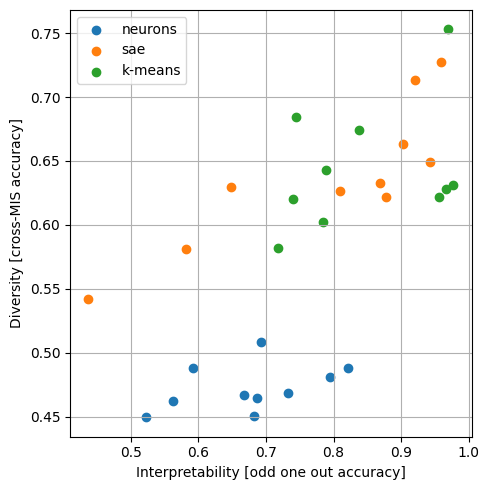

In [31]:
plt.figure(figsize=(5, 5))
for key in codes:
    plt.scatter(
        result_ooo[key]['accuracy_dreamsim'].mean(1)[:10],
        result_cross[key]['accuracy_dreamsim'].mean((1, 2)),
        label=key
    )
plt.legend()
plt.xlabel('Interpretability [odd one out accuracy]')
plt.ylabel('Diversity [cross-MIS accuracy]')
plt.grid()
plt.tight_layout()
save_folder = './Results'
filename = f'{identifier}_{region}_CrossMIS_OOO.png'
file_path = os.path.join(save_folder, filename)
plt.savefig(file_path)
print(f'Saved: {file_path}')